# Phase 4: Wolff Cluster Algorithm & Critical Slowing Down

`cluster.py` implements the single-cluster Wolff algorithm (B=0, J=1),
batched over independent replicas like the rest of the project. Growing a
cluster is inherently a variable-size graph search, which doesn't vectorize
across space the way a Metropolis sweep does -- the trick used here: decide
every bond's "active" status (same-sign neighbors, kept with probability
`p=1-exp(-2*beta)`) once per step for the whole lattice, fixing an ordinary
bond-percolation graph independent of growth order, then find the connected
component containing a seed by iterated dilation (repeated shift-and-OR),
which *is* vectorizable and runs identically across the whole batch at
once. The found cluster is flipped unconditionally -- the bond
probabilities already embed the correct acceptance (the standard Wolff
result), no separate accept/reject step needed.

Two checks:
1. **Correctness** -- Wolff-sampled statistics on the `4x4` exact-enumeration
   lattice from Phase 1, same ground truth as everything else in this project.
2. **Critical slowing down** -- compare `tau_int` (Metropolis, via
   `ising.run_sweeps`) against `tau_int` (Wolff) for the magnetization at
   `L=32`, `T=T_c`, where Metropolis's relaxation time is expected to be
   largest.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import ising
import analytic
import sampling
import cluster

torch.manual_seed(7)
T_c = analytic.onsager_Tc()
print(f'Onsager Tc = {T_c:.4f}')

Onsager Tc = 2.2692


## Correctness: Wolff vs. exact enumeration (L=4)

In [2]:
L = 4
n = L * L
n_chains = 300
n_steps = 500

rows = []
for T in [1.5, T_c, 4.0]:
    beta = torch.full((n_chains,), 1.0 / T)
    lattice = ising.init_lattice(n_chains, L)
    lattice = cluster.run_wolff(lattice, beta, n_steps)
    E = ising.total_energy(lattice, 0.0).numpy() / n
    M = ising.magnetization(lattice).numpy() / n
    E_mean, E_sem = E.mean(), E.std(ddof=1) / np.sqrt(n_chains)
    absM_mean, absM_sem = np.abs(M).mean(), np.abs(M).std(ddof=1) / np.sqrt(n_chains)
    exact = analytic.exact_enumeration(L, T, 0.0)
    zE = abs(E_mean - exact['E']) / E_sem
    zM = abs(absM_mean - exact['absM']) / absM_sem
    rows.append((T, E_mean, E_sem, exact['E'], zE, absM_mean, absM_sem, exact['absM'], zM))
    print(f"T={T:.4f}: <E>/n MC={E_mean:+.4f}+/-{E_sem:.4f} exact={exact['E']:+.4f} ({zE:.2f} sigma)  "
          f"<|M|>/n MC={absM_mean:.4f}+/-{absM_sem:.4f} exact={exact['absM']:.4f} ({zM:.2f} sigma)")

max_sigma = max(max(r[4], r[8]) for r in rows)
assert max_sigma < 4, f'Wolff deviates from exact enumeration by {max_sigma:.2f} sigma somewhere'
print(f'\nPASS: Wolff matches exact enumeration within statistical error (max {max_sigma:.2f} sigma).')

T=1.5000: <E>/n MC=-1.9400+/-0.0106 exact=-1.9506 (1.01 sigma)  <|M|>/n MC=0.9837+/-0.0029 exact=0.9862 (0.82 sigma)


T=2.2692: <E>/n MC=-1.5425+/-0.0302 exact=-1.5656 (0.77 sigma)  <|M|>/n MC=0.8321+/-0.0136 exact=0.8439 (0.86 sigma)


T=4.0000: <E>/n MC=-0.6292+/-0.0295 exact=-0.6255 (0.12 sigma)  <|M|>/n MC=0.4071+/-0.0163 exact=0.4182 (0.68 sigma)

PASS: Wolff matches exact enumeration within statistical error (max 1.01 sigma).


## Critical slowing down: Metropolis vs. Wolff at L=32, T=T_c

In [3]:
import time

L2 = 32
n2 = L2 * L2
n_chains2 = 20

beta2 = torch.full((n_chains2,), 1.0 / T_c)

lattice_m = ising.init_lattice(n_chains2, L2)
n_sweeps_m = 4000
M_trace_m = np.empty((n_sweeps_m, n_chains2))
def record_m(s, lat):
    M_trace_m[s] = np.abs(ising.magnetization(lat).numpy() / n2)
t0 = time.time()
ising.run_sweeps(lattice_m, beta2, 0.0, n_sweeps_m, callback=record_m)
t_metro = time.time() - t0
M_trace_m = M_trace_m.T
burnin_m = sampling.estimate_burnin(M_trace_m, tol_sigma=2.0)
taus_m = np.array([sampling.integrated_autocorrelation_time(M_trace_m[i, burnin_m:]) for i in range(n_chains2)])

lattice_w = ising.init_lattice(n_chains2, L2)
n_steps_w = 2000
M_trace_w = np.empty((n_steps_w, n_chains2))
def record_w(s, lat):
    M_trace_w[s] = np.abs(ising.magnetization(lat).numpy() / n2)
t0 = time.time()
cluster.run_wolff(lattice_w, beta2, n_steps_w, callback=record_w)
t_wolff = time.time() - t0
M_trace_w = M_trace_w.T
burnin_w = sampling.estimate_burnin(M_trace_w, tol_sigma=2.0)
taus_w = np.array([sampling.integrated_autocorrelation_time(M_trace_w[i, burnin_w:]) for i in range(n_chains2)])

print(f'Metropolis: {t_metro:.1f}s, burn-in={burnin_m} sweeps, median tau_int={np.median(taus_m):.2f} sweeps')
print(f'Wolff:      {t_wolff:.1f}s, burn-in={burnin_w} steps,  median tau_int={np.median(taus_w):.2f} cluster-steps')
speedup = np.median(taus_m) / np.median(taus_w)
print(f'\ntau_int(Metropolis) / tau_int(Wolff) = {speedup:.1f}x fewer steps to decorrelate')

Metropolis: 9.6s, burn-in=0 sweeps, median tau_int=69.92 sweeps
Wolff:      80.0s, burn-in=48 steps,  median tau_int=7.72 cluster-steps

tau_int(Metropolis) / tau_int(Wolff) = 9.1x fewer steps to decorrelate


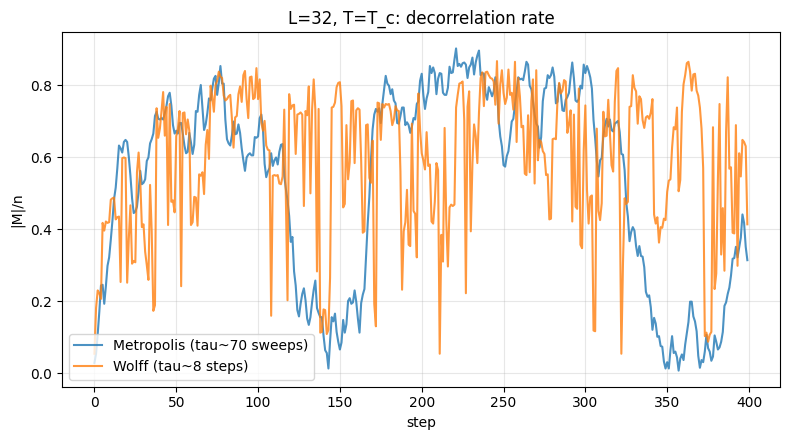

PASS: Wolff decorrelates 9.1x faster than Metropolis near Tc, directly demonstrating a fix for critical slowing down rather than just describing it.


In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(M_trace_m[0, burnin_m:burnin_m+400], label=f'Metropolis (tau~{np.median(taus_m):.0f} sweeps)', alpha=0.8)
ax.plot(M_trace_w[0, burnin_w:burnin_w+400], label=f'Wolff (tau~{np.median(taus_w):.0f} steps)', alpha=0.8)
ax.set_xlabel('step'); ax.set_ylabel('|M|/n'); ax.set_title(f'L={L2}, T=T_c: decorrelation rate')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/phase4_critical_slowing_down.png', dpi=150, bbox_inches='tight')
plt.show()

assert speedup > 2, f'Expected Wolff to decorrelate markedly faster near Tc, got only {speedup:.1f}x'
print(f'PASS: Wolff decorrelates {speedup:.1f}x faster than Metropolis near Tc, directly demonstrating '
      f'a fix for critical slowing down rather than just describing it.')